# SOCIAL MEDIA SENTIMENT

## Import necessary Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

## Import file path

In [3]:
filepath=r"C:\Users\DELL\Downloads\3) Sentiment dataset.csv"

In [4]:
df=pd.read_csv(filepath)

In [5]:
df.describe()

,Unnamed: 0.1,Unnamed: 0,Retweets,Likes,Year,Month,Day,Hour
count,732.000000,732.000000,732.000000,732.000000,732.000000,732.000000,732.000000,732.000000
mean,366.464481,369.740437,21.508197,42.901639,2020.471311,6.122951,15.497268,15.521858
std,211.513936,212.428936,7.061286,14.089848,2.802285,3.411763,8.474553,4.113414
min,0.000000,0.000000,5.000000,10.000000,2010.000000,1.000000,1.000000,0.000000
25%,183.750000,185.750000,17.750000,34.750000,2019.000000,3.000000,9.000000,13.000000
50%,366.500000,370.500000,22.000000,43.000000,2021.000000,6.000000,15.000000,16.000000
75%,549.250000,553.250000,25.000000,50.000000,2023.000000,9.000000,22.000000,19.000000
max,732.000000,736.000000,40.000000,80.000000,2023.000000,12.000000,31.000000,23.000000


## Read file

In [6]:
df.head()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


## Make DataFrame copy

In [7]:
df2=df.copy()

In [9]:
df2=df2.drop(['Unnamed: 0.1','Unnamed: 0'],axis=1)
df2

,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...
727,Collaborating on a science project that receiv...,Happy,2017-08-18 18:20:00,ScienceProjectSuccessHighSchool,Facebook,#ScienceFairWinner #HighSchoolScience,20.0,39.0,UK,2017,8,18,18
728,Attending a surprise birthday party organized ...,Happy,2018-06-22 14:15:00,BirthdayPartyJoyHighSchool,Instagram,#SurpriseCelebration #HighSchoolFriendship,25.0,48.0,USA,2018,6,22,14
729,Successfully fundraising for a school charity ...,Happy,2019-04-05 17:30:00,CharityFundraisingTriumphHighSchool,Twitter,#CommunityGiving #HighSchoolPhilanthropy,22.0,42.0,Canada,2019,4,5,17
730,"Participating in a multicultural festival, cel...",Happy,2020-02-29 20:45:00,MulticulturalFestivalJoyHighSchool,Facebook,#CulturalCelebration #HighSchoolUnity,21.0,43.0,UK,2020,2,29,20


In [10]:
df2

,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...
727,Collaborating on a science project that receiv...,Happy,2017-08-18 18:20:00,ScienceProjectSuccessHighSchool,Facebook,#ScienceFairWinner #HighSchoolScience,20.0,39.0,UK,2017,8,18,18
728,Attending a surprise birthday party organized ...,Happy,2018-06-22 14:15:00,BirthdayPartyJoyHighSchool,Instagram,#SurpriseCelebration #HighSchoolFriendship,25.0,48.0,USA,2018,6,22,14
729,Successfully fundraising for a school charity ...,Happy,2019-04-05 17:30:00,CharityFundraisingTriumphHighSchool,Twitter,#CommunityGiving #HighSchoolPhilanthropy,22.0,42.0,Canada,2019,4,5,17
730,"Participating in a multicultural festival, cel...",Happy,2020-02-29 20:45:00,MulticulturalFestivalJoyHighSchool,Facebook,#CulturalCelebration #HighSchoolUnity,21.0,43.0,UK,2020,2,29,20


## Execute EDA

In [11]:
df2['Sentiment']=df2['Sentiment'].str.strip().str.title()

In [12]:
df2

,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...
727,Collaborating on a science project that receiv...,Happy,2017-08-18 18:20:00,ScienceProjectSuccessHighSchool,Facebook,#ScienceFairWinner #HighSchoolScience,20.0,39.0,UK,2017,8,18,18
728,Attending a surprise birthday party organized ...,Happy,2018-06-22 14:15:00,BirthdayPartyJoyHighSchool,Instagram,#SurpriseCelebration #HighSchoolFriendship,25.0,48.0,USA,2018,6,22,14
729,Successfully fundraising for a school charity ...,Happy,2019-04-05 17:30:00,CharityFundraisingTriumphHighSchool,Twitter,#CommunityGiving #HighSchoolPhilanthropy,22.0,42.0,Canada,2019,4,5,17
730,"Participating in a multicultural festival, cel...",Happy,2020-02-29 20:45:00,MulticulturalFestivalJoyHighSchool,Facebook,#CulturalCelebration #HighSchoolUnity,21.0,43.0,UK,2020,2,29,20


In [11]:
df2['Timestamp']=pd.to_datetime(df2['Timestamp'])

In [12]:
df2

,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...
727,Collaborating on a science project that receiv...,Happy,2017-08-18 18:20:00,ScienceProjectSuccessHighSchool,Facebook,#ScienceFairWinner #HighSchoolScience,20.0,39.0,UK,2017,8,18,18
728,Attending a surprise birthday party organized ...,Happy,2018-06-22 14:15:00,BirthdayPartyJoyHighSchool,Instagram,#SurpriseCelebration #HighSchoolFriendship,25.0,48.0,USA,2018,6,22,14
729,Successfully fundraising for a school charity ...,Happy,2019-04-05 17:30:00,CharityFundraisingTriumphHighSchool,Twitter,#CommunityGiving #HighSchoolPhilanthropy,22.0,42.0,Canada,2019,4,5,17
730,"Participating in a multicultural festival, cel...",Happy,2020-02-29 20:45:00,MulticulturalFestivalJoyHighSchool,Facebook,#CulturalCelebration #HighSchoolUnity,21.0,43.0,UK,2020,2,29,20


In [15]:
text_col=df2.select_dtypes(include='object').columns
for col in text_col:
      df2[col]=df[col].str.strip().str.title()


    

In [16]:
df2['Likes']=df2['Likes'].round(0).astype(int)

In [17]:
df2.set_index(df2.User,inplace=True)

In [18]:
df2

,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
User,,,,,,,,,,,,,
User123,Enjoying A Beautiful Day At The Park!,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30,Usa,2023,1,15,12
Commuterx,Traffic Was Terrible This Morning.,Negative,2023-01-15 08:45:00,Commuterx,Twitter,#Traffic #Morning,5.0,10,Canada,2023,1,15,8
Fitnessfan,Just Finished An Amazing Workout! 💪,Positive,2023-01-15 15:45:00,Fitnessfan,Instagram,#Fitness #Workout,20.0,40,Usa,2023,1,15,15
Adventurex,Excited About The Upcoming Weekend Getaway!,Positive,2023-01-15 18:20:00,Adventurex,Facebook,#Travel #Adventure,8.0,15,Uk,2023,1,15,18
Chefcook,Trying Out A New Recipe For Dinner Tonight.,Neutral,2023-01-15 19:55:00,Chefcook,Instagram,#Cooking #Food,12.0,25,Australia,2023,1,15,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...
Scienceprojectsuccesshighschool,Collaborating On A Science Project That Receiv...,Happy,2017-08-18 18:20:00,Scienceprojectsuccesshighschool,Facebook,#Sciencefairwinner #Highschoolscience,20.0,39,Uk,2017,8,18,18
Birthdaypartyjoyhighschool,Attending A Surprise Birthday Party Organized ...,Happy,2018-06-22 14:15:00,Birthdaypartyjoyhighschool,Instagram,#Surprisecelebration #Highschoolfriendship,25.0,48,Usa,2018,6,22,14
Charityfundraisingtriumphhighschool,Successfully Fundraising For A School Charity ...,Happy,2019-04-05 17:30:00,Charityfundraisingtriumphhighschool,Twitter,#Communitygiving #Highschoolphilanthropy,22.0,42,Canada,2019,4,5,17


In [19]:
df2.loc[(df2['Platform']=='Twitter')&(df2['Sentiment'] !='Positive')]

,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
User,,,,,,,,,,,,,
Commuterx,Traffic Was Terrible This Morning.,Negative,2023-01-15 08:45:00,Commuterx,Twitter,#Traffic #Morning,5.0,10,Canada,2023,1,15,8
Debatetalk,Political Discussions Heating Up On The Timeline.,Negative,2023-01-17 08:00:00,Debatetalk,Twitter,#Politics #Debate,30.0,60,Usa,2023,1,17,8
Wellnesscheck,Feeling A Bit Under The Weather Today.,Negative,2023-01-18 10:30:00,Wellnesscheck,Twitter,#Sickday #Health,7.0,15,Canada,2023,1,18,10
Techenthusiast,Technology Is Changing The Way We Live.,Neutral,2023-01-19 09:45:00,Techenthusiast,Twitter,#Tech #Innovation,15.0,30,India,2023,1,19,9
Socialjustice,Can'T Believe The Injustice Happening In Our S...,Anger,2023-02-11 09:30:00,Socialjustice,Twitter,#Injustice #Angry,20.0,40,Canada,2023,2,11,9
...,...,...,...,...,...,...,...,...,...,...,...,...,...
Debateclubparticipationhighschool,Participating In A Debate Club To Enhance Crit...,Neutral,2023-10-15 20:45:00,Debateclubparticipationhighschool,Twitter,#Debateskills #Highschoolintellect,22.0,43,Canada,2023,10,15,20
Codingsuccesshighschool,Successfully Completing A Challenging Coding P...,Happy,2023-10-17 12:30:00,Codingsuccesshighschool,Twitter,#Codingtriumph #Highschooltech,24.0,48,Usa,2023,10,17,12
Sportsvictoryhighschool,Winning A Friendly Sports Competition Against ...,Happy,2023-10-20 14:15:00,Sportsvictoryhighschool,Twitter,#Sportstriumph #Highschoolathletics,26.0,50,Usa,2023,10,20,14


In [13]:
df2.groupby(by=df2['Platform'])['Likes'].agg(['sum','mean','count']).sort_values(by=['sum'],ascending=False)

,sum,mean,count
Platform,,,
Instagram,11633.0,45.089147,258
Facebook,9672.0,41.870130,231
Twitter,5809.0,45.382812,128
Twitter,4290.0,37.304348,115


In [22]:
df2['Retweets']=df2['Retweets'].astype(int).round(0)

In [24]:
Countries_likes=df2.groupby(by=['Country','Platform'])[['Likes','Retweets']].sum().sort_values(by=['Likes'],ascending=False)
Countries_likes

,,Likes,Retweets
Country,Platform,,
UK,Instagram,1100.0,555.0
USA,Instagram,990.0,499.0
USA,Twitter,953.0,476.0
Canada,Twitter,908.0,458.0
USA,Facebook,904.0,455.0
...,...,...,...
Canada,Instagram,30.0,15.0
USA,Instagram,30.0,15.0
Canada,Facebook,25.0,12.0


In [24]:
df2.describe()

,Timestamp,Retweets,Likes,Year,Month,Day,Hour
count,732,732.000000,732.000000,732.000000,732.000000,732.000000,732.000000
mean,2020-12-08 21:37:38.196721408,21.508197,42.901639,2020.471311,6.122951,15.497268,15.521858
min,2010-05-15 15:30:00,5.000000,10.000000,2010.000000,1.000000,1.000000,0.000000
25%,2019-03-08 17:27:30,17.750000,34.750000,2019.000000,3.000000,9.000000,13.000000
50%,2021-09-20 14:30:00,22.000000,43.000000,2021.000000,6.000000,15.000000,16.000000
75%,2023-02-26 11:48:45,25.000000,50.000000,2023.000000,9.000000,22.000000,19.000000
max,2023-10-22 20:45:00,40.000000,80.000000,2023.000000,12.000000,31.000000,23.000000
std,NaN,7.061286,14.089848,2.802285,3.411763,8.474553,4.113414


In [34]:

num_only=df2.select_dtypes(include=['float64','int64'])
num_only


,Retweets,Likes,Year,Month,Day,Hour
User,,,,,,
User123,15,30,2023,1,15,12
Commuterx,5,10,2023,1,15,8
Fitnessfan,20,40,2023,1,15,15
Adventurex,8,15,2023,1,15,18
Chefcook,12,25,2023,1,15,19
...,...,...,...,...,...,...
Scienceprojectsuccesshighschool,20,39,2017,8,18,18
Birthdaypartyjoyhighschool,25,48,2018,6,22,14
Charityfundraisingtriumphhighschool,22,42,2019,4,5,17


In [ ]:
num_only.corr()
# Correlation is between Retweets and Likes, which is 0.998, indicating a strong positive correlation. This means that as the number of retweets increases, the number of likes also tends to increase, and vice versa.

,Retweets,Likes,Year,Month,Day,Hour
Retweets,1.000000,0.998482,-0.039982,0.073265,0.009213,0.196955
Likes,0.998482,1.000000,-0.043415,0.066643,0.011489,0.195331
Year,-0.039982,-0.043415,1.000000,-0.314845,0.021973,-0.087470
Month,0.073265,0.066643,-0.314845,1.000000,-0.135873,0.137835
Day,0.009213,0.011489,0.021973,-0.135873,1.000000,0.044072
Hour,0.196955,0.195331,-0.087470,0.137835,0.044072,1.000000


In [ ]:
df2.info()

In [ ]:
Num_Users.plot(
    kind='bar')
plt.xlabel('Platform')
plt.ylabel('Users')
plt.xticks(rotation=45)     # tilt x labels if they overlap
plt.tight_layout()           # prevents labels from being cut off
plt.show()

In [ ]:
df2.info()

In [ ]:
# TOP 5 USERS

Top5_users=df2.groupby(by=df2.User)['Likes'].sum().sort_values(ascending=False).head(5)
print(f'Here are the Top 5: {Top5_users}')

Here are the Top 5: User
Winterwarmth       170
Bookworm           165
Cosmosexplorer     160
Forestdreamer      160
Carnivaldreamer    144
Name: Likes, dtype: int64


In [ ]:
# BOTTOM 5 USERS

Bottom5_users=df2.groupby(by=df2.User)['Likes'].sum().sort_values(ascending=True).head(5)
print(f'Here are the Top 5: {Bottom5_users}')

Here are the Top 5: User
Commuterx         10
Strugglingsoul    10
Wellnesscheck     15
Adventurex        15
Mundaneheart      15
Name: Likes, dtype: int64


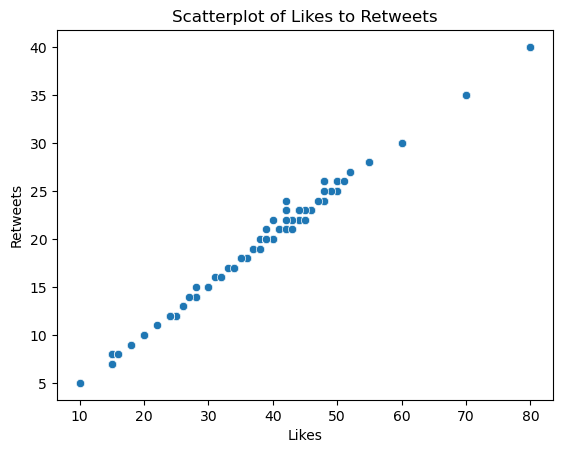

In [ ]:
# AS SHOWN FROM THE SCATTERPLOT THERE IS A POSITIVE LINEAER RELATIONSHIP BETWEEN LIKES AND RETWEETS.

sns.scatterplot(df2,x=df2['Likes'],y=df2['Retweets'])
plt.title('Scatterplot of Likes to Retweets')
plt.show()

C:\Users\DELL\AppData\Local\Temp\ipykernel_17900\2851720846.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(Top5_users,palette=['red','green','blue','yellow','black'])


<Axes: xlabel='User', ylabel='Likes'>

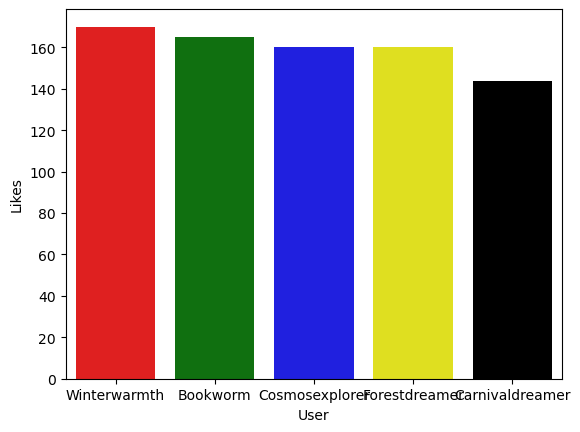

In [ ]:
# BARPLOT DEPICTING THE TOP 5 USERS 

sns.barplot(Top5_users,palette=['red','green','blue','yellow','black'])

df2

In [ ]:
df2[df2['Text'].str[0:2].str.contains(r'^[a-z\s]+',case=False)]

,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
User,,,,,,,,,,,,,
User123,Enjoying A Beautiful Day At The Park!,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15,30,Usa,2023,1,15,12
Commuterx,Traffic Was Terrible This Morning.,Negative,2023-01-15 08:45:00,Commuterx,Twitter,#Traffic #Morning,5,10,Canada,2023,1,15,8
Fitnessfan,Just Finished An Amazing Workout! 💪,Positive,2023-01-15 15:45:00,Fitnessfan,Instagram,#Fitness #Workout,20,40,Usa,2023,1,15,15
Adventurex,Excited About The Upcoming Weekend Getaway!,Positive,2023-01-15 18:20:00,Adventurex,Facebook,#Travel #Adventure,8,15,Uk,2023,1,15,18
Chefcook,Trying Out A New Recipe For Dinner Tonight.,Neutral,2023-01-15 19:55:00,Chefcook,Instagram,#Cooking #Food,12,25,Australia,2023,1,15,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...
Scienceprojectsuccesshighschool,Collaborating On A Science Project That Receiv...,Happy,2017-08-18 18:20:00,Scienceprojectsuccesshighschool,Facebook,#Sciencefairwinner #Highschoolscience,20,39,Uk,2017,8,18,18
Birthdaypartyjoyhighschool,Attending A Surprise Birthday Party Organized ...,Happy,2018-06-22 14:15:00,Birthdaypartyjoyhighschool,Instagram,#Surprisecelebration #Highschoolfriendship,25,48,Usa,2018,6,22,14
Charityfundraisingtriumphhighschool,Successfully Fundraising For A School Charity ...,Happy,2019-04-05 17:30:00,Charityfundraisingtriumphhighschool,Twitter,#Communitygiving #Highschoolphilanthropy,22,42,Canada,2019,4,5,17


In [ ]:
import re

df2['Text'] = df2['Text'].str.replace(r'[^\w\s]', '', regex=True)

In [ ]:
df2

,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
User,,,,,,,,,,,,,
User123,Enjoying A Beautiful Day At The Park,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15,30,Usa,2023,1,15,12
Commuterx,Traffic Was Terrible This Morning,Negative,2023-01-15 08:45:00,Commuterx,Twitter,#Traffic #Morning,5,10,Canada,2023,1,15,8
Fitnessfan,Just Finished An Amazing Workout,Positive,2023-01-15 15:45:00,Fitnessfan,Instagram,#Fitness #Workout,20,40,Usa,2023,1,15,15
Adventurex,Excited About The Upcoming Weekend Getaway,Positive,2023-01-15 18:20:00,Adventurex,Facebook,#Travel #Adventure,8,15,Uk,2023,1,15,18
Chefcook,Trying Out A New Recipe For Dinner Tonight,Neutral,2023-01-15 19:55:00,Chefcook,Instagram,#Cooking #Food,12,25,Australia,2023,1,15,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...
Scienceprojectsuccesshighschool,Collaborating On A Science Project That Receiv...,Happy,2017-08-18 18:20:00,Scienceprojectsuccesshighschool,Facebook,#Sciencefairwinner #Highschoolscience,20,39,Uk,2017,8,18,18
Birthdaypartyjoyhighschool,Attending A Surprise Birthday Party Organized ...,Happy,2018-06-22 14:15:00,Birthdaypartyjoyhighschool,Instagram,#Surprisecelebration #Highschoolfriendship,25,48,Usa,2018,6,22,14
Charityfundraisingtriumphhighschool,Successfully Fundraising For A School Charity ...,Happy,2019-04-05 17:30:00,Charityfundraisingtriumphhighschool,Twitter,#Communitygiving #Highschoolphilanthropy,22,42,Canada,2019,4,5,17


In [8]:
df2.to_csv('bootz.csv',index=False)